In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import os
import os.path
from os import path

import cv2
import PIL
import PIL.Image
from PIL import Image

import pathlib
from pathlib import Path
import imghdr
import shutil

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential

/tmp/ipython-input-4047033521.py:15: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip 'drive/MyDrive/image_set.zip'

Archive:  drive/MyDrive/image_set.zip
   creating: content/images/
   creating: content/images/cat_images/
  inflating: content/images/cat_images/000087.jpg  
  inflating: content/images/cat_images/000053.jpg  
  inflating: content/images/cat_images/000125.jpg  
  inflating: content/images/cat_images/000090.jpg  
  inflating: content/images/cat_images/000140.jpg  
  inflating: content/images/cat_images/000117.jpg  
  inflating: content/images/cat_images/000038.jpg  
  inflating: content/images/cat_images/000049.jpg  
  inflating: content/images/cat_images/000077.jpg  
  inflating: content/images/cat_images/000128.jpg  
  inflating: content/images/cat_images/000024.jpg  
  inflating: content/images/cat_images/000148.jpg  
  inflating: content/images/cat_images/000048.jpg  
  inflating: content/images/cat_images/000150.jpg  
  inflating: content/images/cat_images/000133.jpg  
  inflating: content/images/cat_images/000006.jpg  
  inflating: content/images/cat_images/000104.jpg  
  inflati

In [ ]:
!unzip '/content/image_set.zip'

unzip:  cannot find or open /content/image_set.zip, /content/image_set.zip.zip or /content/image_set.zip.ZIP.


In [ ]:
# You can check if the code ran correctly by checking the uploaded folders on Canvas
data_dir = 'content/images/'
# Take note of the folder you have created for invalid data
# This will be used later to check and filter out the "bad" images from our dataset
os.mkdir('content/invalid_images')

In [ ]:
Image.open('content/images/frog_images/000001.jpg')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
def check_images(s_dir, ext_list):
    bad_images=[]
    bad_ext=[]
    s_list= os.listdir(s_dir)
    for klass in s_list:
        klass_path=os.path.join (s_dir, klass)
        print ('processing class directory ', klass)
        if os.path.isdir(klass_path):
            file_list=os.listdir(klass_path)
            for f in file_list:
                f_path=os.path.join (klass_path,f)
                index=f.rfind('.')
                ext=f[index+1:].lower()
                if ext not in ext_list:
                    print('file ', f_path, ' has an invalid extension ', ext)
                    bad_ext.append(f_path)
                if os.path.isfile(f_path):
                    try:
                        img=cv2.imread(f_path)
                        shape=img.shape
                    except:
                        print('file ', f_path, ' is not a valid image file')
                        bad_images.append(f_path)
                else:
                    print('*** fatal error, you a sub directory ', f, ' in class directory ', klass)
        else:
            print ('*** WARNING*** you have files in ', s_dir, ' it should only contain sub directories')
    return bad_images, bad_ext

# Change the folder path below to the folder of your data that you have uploaded
source_dir =r'content/images/'
# This is a test code to check if any files that you have downloaded have incorrect extensions
# The allowed extensions are listed below
good_exts=['jpg', 'png', 'jpeg', 'gif', 'bmp']
bad_file_list, bad_ext_list=check_images(source_dir, good_exts)
if len(bad_file_list) !=0:
    print('improper image files are listed below')
    for i in range (len(bad_file_list)):
        print (bad_file_list[i])
else:
    print(' no improper image files were found')

processing class directory  frog_images
processing class directory  snake_image
processing class directory  bird_images
processing class directory  cat_images
 no improper image files were found


In [ ]:
# Change the folder path below to the folder of your data that you have uploaded
source_dir = "content/images/"
# Change the folder name below to the folder for invalid images that you created earlier
destination_folder_path = 'content/invalid_images'
# The image extensions below should list all the file extensions that are being used in your dataset
image_extensions = [".png", ".jpg", '.bmp', '.jpeg']
img_type_accepted_by_tf = ["bmp", "gif", "jpeg", "png"]
for filepath in Path(source_dir).rglob("*"):
    if filepath.suffix.lower() in image_extensions:
        img_type = imghdr.what(filepath)
        destination_file_path = os.path.join(destination_folder_path, os.path.basename(filepath))
        if img_type is None:
            print(f"{filepath} is not an image")
            shutil.move(filepath, destination_file_path)
        elif img_type not in img_type_accepted_by_tf:
            print(f"{filepath} is a {img_type}, not accepted by TensorFlow")
            shutil.move(filepath, destination_file_path)

content/images/frog_images/000120.jpg is a webp, not accepted by TensorFlow
content/images/frog_images/000052.jpg is not an image
content/images/frog_images/000042.jpg is a webp, not accepted by TensorFlow
content/images/frog_images/000136.jpg is not an image
content/images/snake_image/000035.jpg is not an image
content/images/snake_image/000126.jpg is a webp, not accepted by TensorFlow
content/images/snake_image/000060.jpg is a webp, not accepted by TensorFlow
content/images/snake_image/000104.jpg is not an image
content/images/snake_image/000038.jpg is not an image
content/images/snake_image/000105.jpg is not an image
content/images/bird_images/000018.jpg is not an image
content/images/bird_images/000044.jpg is not an image
content/images/bird_images/000035.jpg is a webp, not accepted by TensorFlow
content/images/bird_images/000023.jpg is not an image
content/images/bird_images/000010.jpg is not an image
content/images/bird_images/000064.jpg is a webp, not accepted by TensorFlow
cont

In [ ]:
batch_size = 32
img_height = 640
img_width = 640

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 493 files belonging to 4 classes.
Using 395 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 493 files belonging to 4 classes.
Using 98 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['bird_images', 'cat_images', 'frog_images', 'snake_image']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
normalization_layer = layers.Rescaling(1./255)

normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# This should print out a range of values that resembles [0, 1]
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [ ]:
num_classes = len(class_names)

model = Sequential([
  # Sequential Layer 1
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  # Sequential Layer 2
  layers.Conv2D(164, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  # Flatten Layers
  layers.Flatten(),
  # Output Layer
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10


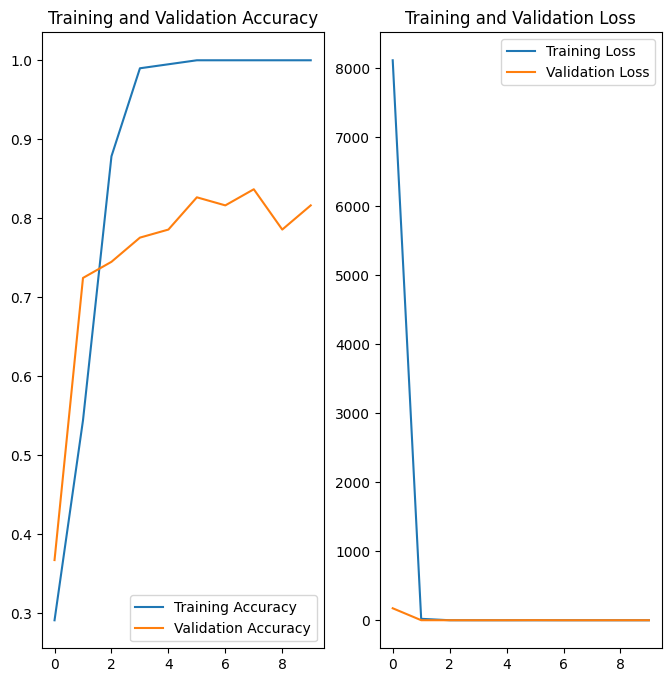

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Just replace the "test_image_url" with the URL of the image you would like to test
bird = "https://cdn.britannica.com/10/250610-050-BC5CCDAF/Zebra-finch-Taeniopygia-guttata-bird.jpg"
# Change the "test_image_path" data with the name of the image that you will be testing against the model
test_image_path = tf.keras.utils.get_file('bird', origin=bird)

img = tf.keras.utils.load_img(
    test_image_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

119825/119825 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
This image most likely belongs to cat_images with a 99.82 percent confidence.
